# Практична робота: Регресія та Класифікація з Використанням TensorFlow

**Мета:**
- Освоїти методи генерації даних для задач регресії та класифікації.
- Побудувати нейронні мережі для аналізу згенерованих даних.
- Застосувати TensorFlow для навчання моделей.

**Номер за журналом: 33** → кількість даних = 1000×33 = **33 000**, кількість класів = 33+2 = **35**.

## 0. Імпорт бібліотек та налаштування

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from IPython.display import HTML
import seaborn as sns

from sklearn.datasets import make_regression, make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, accuracy_score, confusion_matrix
from sklearn.decomposition import PCA

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (8, 5)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

STUDENT_NUMBER = 33
N_SAMPLES = 1000 * STUDENT_NUMBER
N_CLASSES = STUDENT_NUMBER + 2

print(f"Номер за журналом: {STUDENT_NUMBER}")
print(f"Кількість зразків (для обох задач): {N_SAMPLES}")
print(f"Кількість класів (класифікація): {N_CLASSES}")
print("TensorFlow версія:", tf.__version__)

Номер за журналом: 33
Кількість зразків (для обох задач): 33000
Кількість класів (класифікація): 35
TensorFlow версія: 2.22.0-rc0


## 1. Генерація даних

### 1.1 Задача регресії — `make_regression`

In [2]:
X_reg, y_reg = make_regression(
    n_samples=N_SAMPLES,
    n_features=10,
    n_informative=6,
    noise=15.0,
    random_state=RANDOM_STATE,
)

print("X_reg:", X_reg.shape, " y_reg:", y_reg.shape)

reg_df = pd.DataFrame(X_reg, columns=[f"feature_{i+1}" for i in range(X_reg.shape[1])])
reg_df["target"] = y_reg
reg_df.head()

X_reg: (33000, 10)  y_reg: (33000,)


,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,feature_10,target
0,-0.471618,0.865738,0.441879,-0.086364,1.476193,-1.010532,0.380677,0.585032,-0.350801,-1.310587,115.412813
1,-1.153988,-0.924978,0.555365,-0.613421,-0.003495,-1.109806,0.491880,0.602453,-0.969564,-1.871018,-29.838542
2,0.460549,-0.164212,0.713935,0.942225,-0.052319,0.394787,-0.304637,-0.612243,0.872450,0.408814,23.142711
3,0.654210,1.904771,0.194015,-0.176470,-0.906710,1.064097,-1.229625,0.389312,-0.230412,0.995254,154.578517
4,0.986192,-0.094508,-0.749914,-0.739173,0.844705,0.362733,-0.475093,-1.525460,2.035939,0.087436,-84.288208


### 1.2 Візуалізація даних регресії

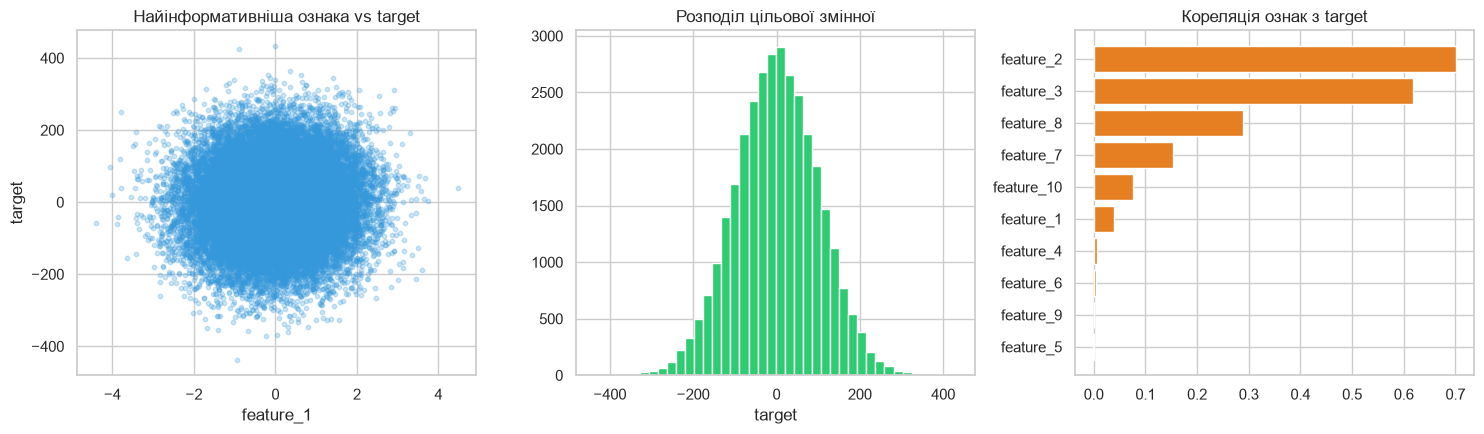

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

axes[0].scatter(X_reg[:, 0], y_reg, alpha=0.25, s=10, color="#3498db")
axes[0].set_title("Найінформативніша ознака vs target")
axes[0].set_xlabel("feature_1")
axes[0].set_ylabel("target")

axes[1].hist(y_reg, bins=40, color="#2ecc71")
axes[1].set_title("Розподіл цільової змінної")
axes[1].set_xlabel("target")

corr = reg_df.corr()["target"].drop("target").sort_values()
axes[2].barh(corr.index, corr.values, color="#e67e22")
axes[2].set_title("Кореляція ознак з target")

plt.tight_layout()
plt.show()

### 1.3 Задача класифікації — `make_classification`

Для коректної генерації 35 класів встановлюємо `n_informative` достатньо великим
(потрібно `n_classes * n_clusters_per_class <= 2**n_informative`).

In [4]:
X_clf, y_clf = make_classification(
    n_samples=N_SAMPLES,
    n_features=20,
    n_informative=15,
    n_redundant=3,
    n_repeated=0,
    n_classes=N_CLASSES,
    n_clusters_per_class=1,
    class_sep=1.5,
    random_state=RANDOM_STATE,
)

print("X_clf:", X_clf.shape, " y_clf:", y_clf.shape, " Кількість класів:", len(np.unique(y_clf)))

X_clf: (33000, 20)  y_clf: (33000,)  Кількість класів: 35


### 1.4 Візуалізація даних класифікації (PCA-проєкція у 2D)

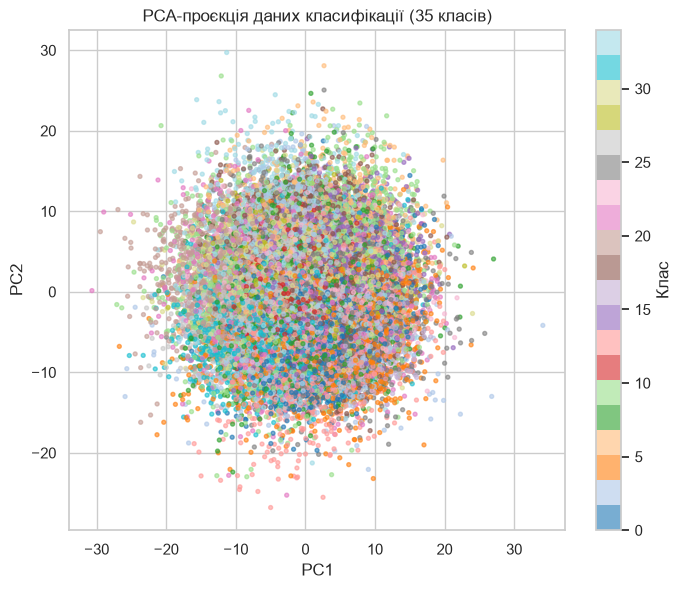

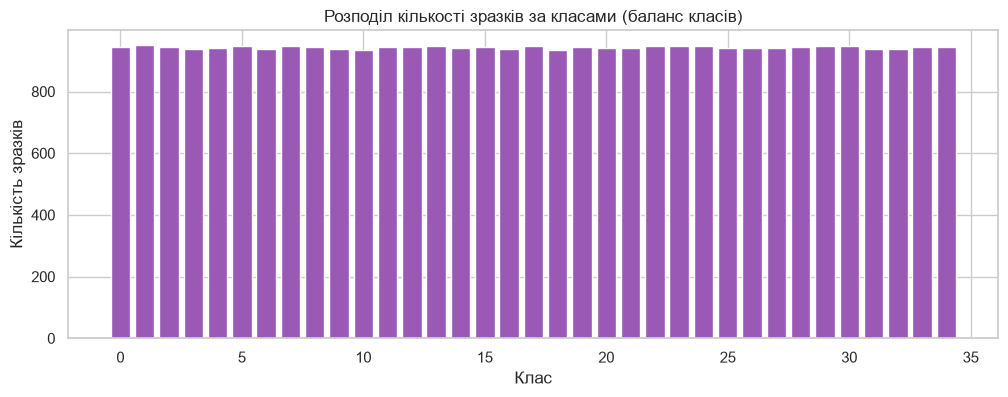

In [5]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_clf_2d = pca.fit_transform(X_clf)

fig, ax = plt.subplots(figsize=(8, 6.5))
scatter = ax.scatter(X_clf_2d[:, 0], X_clf_2d[:, 1], c=y_clf, cmap="tab20", s=8, alpha=0.6)
ax.set_title(f"PCA-проєкція даних класифікації ({N_CLASSES} класів)")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
plt.colorbar(scatter, label="Клас")
plt.show()

class_counts = pd.Series(y_clf).value_counts().sort_index()
fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(class_counts.index, class_counts.values, color="#9b59b6")
ax.set_title("Розподіл кількості зразків за класами (баланс класів)")
ax.set_xlabel("Клас")
ax.set_ylabel("Кількість зразків")
plt.show()

---
## 2. Побудова та навчання моделей

### 2.1 Підготовка даних

In [6]:
# --- Регресія: розподіл і масштабування ---
Xr_train, Xr_test, yr_train, yr_test = train_test_split(X_reg, y_reg, test_size=0.2, random_state=RANDOM_STATE)

reg_scaler_X = StandardScaler().fit(Xr_train)
Xr_train_s = reg_scaler_X.transform(Xr_train)
Xr_test_s = reg_scaler_X.transform(Xr_test)

reg_scaler_y = StandardScaler().fit(yr_train.reshape(-1, 1))
yr_train_s = reg_scaler_y.transform(yr_train.reshape(-1, 1)).ravel()
yr_test_s = reg_scaler_y.transform(yr_test.reshape(-1, 1)).ravel()

# --- Класифікація: розподіл і масштабування ---
Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=RANDOM_STATE, stratify=y_clf
)

clf_scaler_X = StandardScaler().fit(Xc_train)
Xc_train_s = clf_scaler_X.transform(Xc_train)
Xc_test_s = clf_scaler_X.transform(Xc_test)

print("Регресія:  train", Xr_train_s.shape, " test", Xr_test_s.shape)
print("Класифікація: train", Xc_train_s.shape, " test", Xc_test_s.shape)

Регресія:  train (26400, 10)  test (6600, 10)
Класифікація: train (26400, 20)  test (6600, 20)


### 2.2 Нейронна мережа для регресії (TensorFlow / Keras)

In [7]:
reg_model = keras.Sequential([
    layers.Input(shape=(Xr_train_s.shape[1],)),
    layers.Dense(64, activation="relu"),
    layers.Dense(32, activation="relu"),
    layers.Dense(16, activation="relu"),
    layers.Dense(1),  # лінійний вихід для регресії
], name="regression_model")

reg_model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
                   loss="mse", metrics=["mae"])

reg_model.summary()

Model: "regression_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,329 (13.00 KB)

 Trainable params: 3,329 (13.00 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
reg_history = reg_model.fit(
    Xr_train_s, yr_train_s,
    validation_split=0.15,
    epochs=60,
    batch_size=64,
    verbose=0,
)
print("Навчання завершено. Фінальний val_loss:", round(reg_history.history["val_loss"][-1], 4))

Навчання завершено. Фінальний val_loss: 0.0263


### 2.3 Нейронна мережа для класифікації (TensorFlow / Keras)

In [9]:
clf_model = keras.Sequential([
    layers.Input(shape=(Xc_train_s.shape[1],)),
    layers.Dense(128, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(64, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(N_CLASSES, activation="softmax"),  # softmax для багатокласової класифікації
], name="classification_model")

clf_model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
                   loss="sparse_categorical_crossentropy", metrics=["accuracy"])

clf_model.summary()

Model: "classification_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 128)            │         2,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 35)             │         2,275 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,987 (54.64 KB)

 Trainable params: 13,603 (53.14 KB)

 Non-trainable params: 384 (1.50 KB)

In [10]:
early_stop = keras.callbacks.EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True)

clf_history = clf_model.fit(
    Xc_train_s, yc_train,
    validation_split=0.15,
    epochs=80,
    batch_size=128,
    callbacks=[early_stop],
    verbose=0,
)
print("Навчання завершено за", len(clf_history.history["loss"]), "епох.")
print("Фінальна val_accuracy:", round(clf_history.history["val_accuracy"][-1], 4))

Навчання завершено за 77 епох.
Фінальна val_accuracy: 0.8624


---
## 3. Оцінка моделей

### 3.1 Регресія — криві навчання та Mean Squared Error

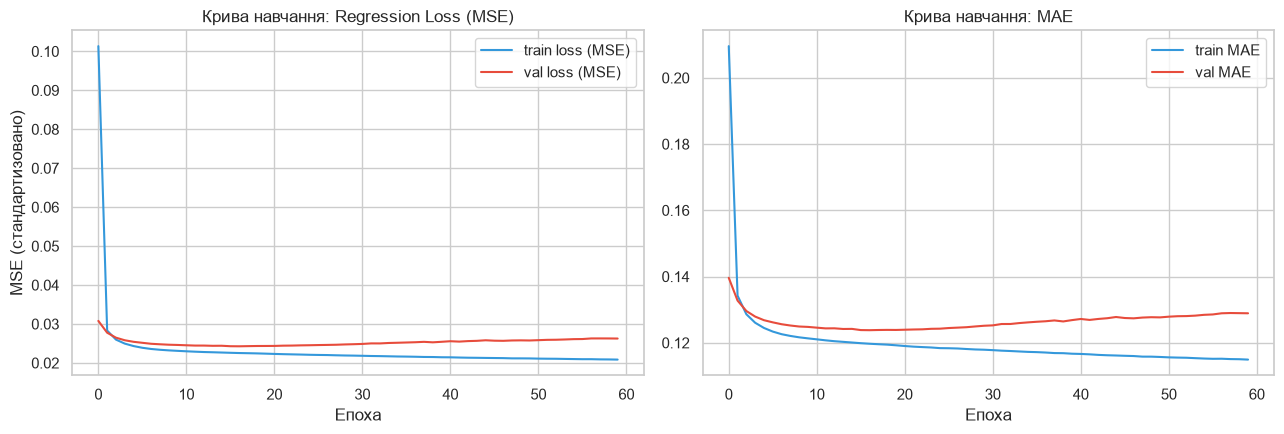

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(reg_history.history["loss"], label="train loss (MSE)", color="#3498db")
axes[0].plot(reg_history.history["val_loss"], label="val loss (MSE)", color="#e74c3c")
axes[0].set_title("Крива навчання: Regression Loss (MSE)")
axes[0].set_xlabel("Епоха")
axes[0].set_ylabel("MSE (стандартизовано)")
axes[0].legend()

axes[1].plot(reg_history.history["mae"], label="train MAE", color="#3498db")
axes[1].plot(reg_history.history["val_mae"], label="val MAE", color="#e74c3c")
axes[1].set_title("Крива навчання: MAE")
axes[1].set_xlabel("Епоха")
axes[1].legend()

plt.tight_layout()
plt.show()

In [12]:
yr_pred_s = reg_model.predict(Xr_test_s, verbose=0).ravel()

# Повертаємо у вихідний масштаб для інтерпретованого MSE
yr_pred = reg_scaler_y.inverse_transform(yr_pred_s.reshape(-1, 1)).ravel()

mse = mean_squared_error(yr_test, yr_pred)
rmse = mse ** 0.5
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root MSE (RMSE): {rmse:.4f}")

Mean Squared Error (MSE): 255.5359
Root MSE (RMSE): 15.9855


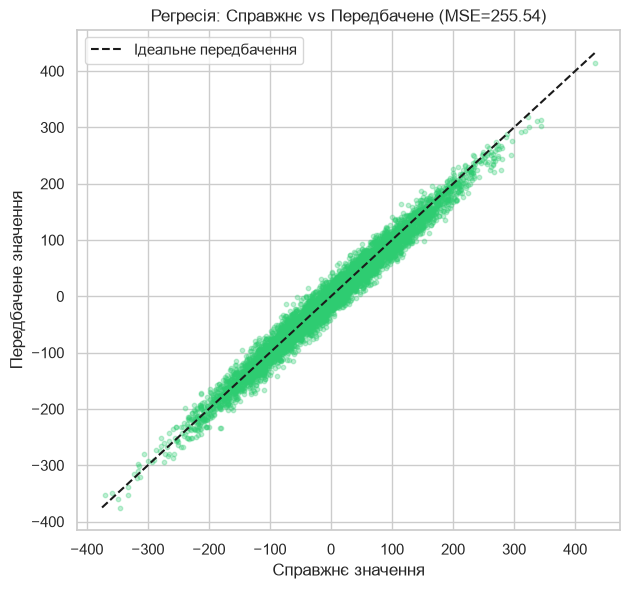

In [13]:
fig, ax = plt.subplots(figsize=(7, 6.5))
ax.scatter(yr_test, yr_pred, alpha=0.3, s=10, color="#2ecc71")
lims = [min(yr_test.min(), yr_pred.min()), max(yr_test.max(), yr_pred.max())]
ax.plot(lims, lims, "k--", label="Ідеальне передбачення")
ax.set_xlabel("Справжнє значення")
ax.set_ylabel("Передбачене значення")
ax.set_title(f"Регресія: Справжнє vs Передбачене (MSE={mse:.2f})")
ax.legend()
plt.show()

### 3.2 Анімована крива навчання регресії

In [14]:
train_loss = reg_history.history["loss"]
val_loss = reg_history.history["val_loss"]
epochs_range = list(range(1, len(train_loss) + 1))

fig, ax = plt.subplots(figsize=(7.5, 5))
ax.set_xlim(1, len(train_loss))
ax.set_ylim(0, max(max(train_loss), max(val_loss)) * 1.1)
ax.set_xlabel("Епоха")
ax.set_ylabel("Loss (MSE)")
ax.set_title("Анімація навчання: Regression Loss")

line_train, = ax.plot([], [], color="#3498db", linewidth=2, label="train loss")
line_val, = ax.plot([], [], color="#e74c3c", linewidth=2, label="val loss")
ax.legend()

def init():
    line_train.set_data([], [])
    line_val.set_data([], [])
    return line_train, line_val

def update(frame):
    line_train.set_data(epochs_range[:frame], train_loss[:frame])
    line_val.set_data(epochs_range[:frame], val_loss[:frame])
    return line_train, line_val

anim_reg = FuncAnimation(fig, update, frames=len(train_loss)+1, init_func=init, interval=60, blit=True)
anim_reg.save("regression_training.gif", writer=PillowWriter(fps=15))
plt.close(fig)

HTML('<img src="regression_training.gif">')

### 3.3 Класифікація — Accuracy та матриця плутанини

In [15]:
yc_pred_proba = clf_model.predict(Xc_test_s, verbose=0)
yc_pred = np.argmax(yc_pred_proba, axis=1)

test_accuracy = accuracy_score(yc_test, yc_pred)
print(f"Accuracy на тестовій вибірці: {test_accuracy:.4f}")

Accuracy на тестовій вибірці: 0.8538


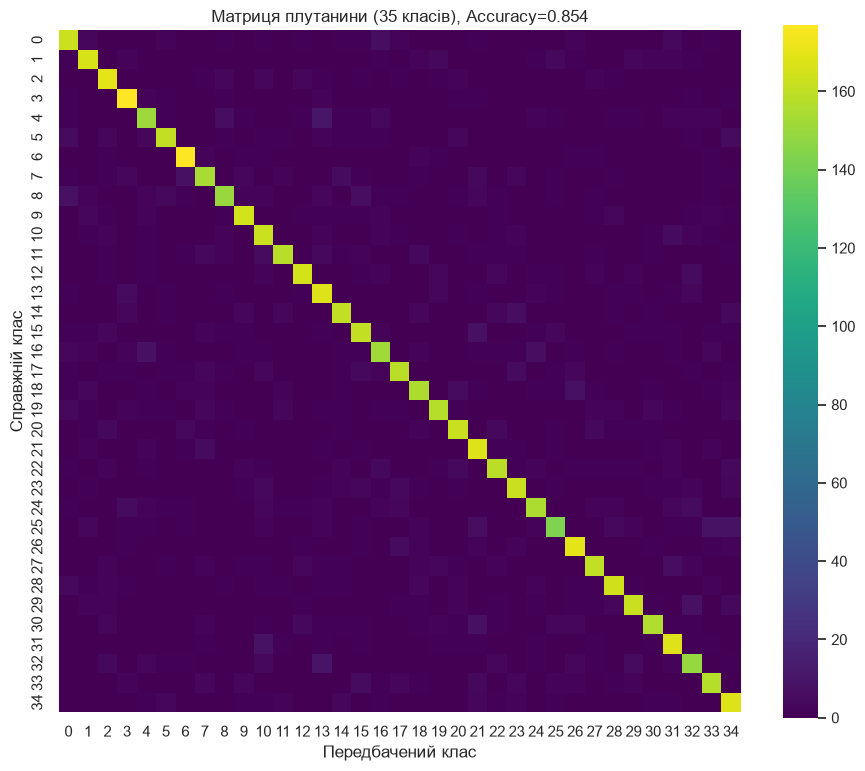

In [16]:
cm = confusion_matrix(yc_test, yc_pred)

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(cm, cmap="viridis", cbar=True, ax=ax, square=True)
ax.set_title(f"Матриця плутанини ({N_CLASSES} класів), Accuracy={test_accuracy:.3f}")
ax.set_xlabel("Передбачений клас")
ax.set_ylabel("Справжній клас")
plt.show()

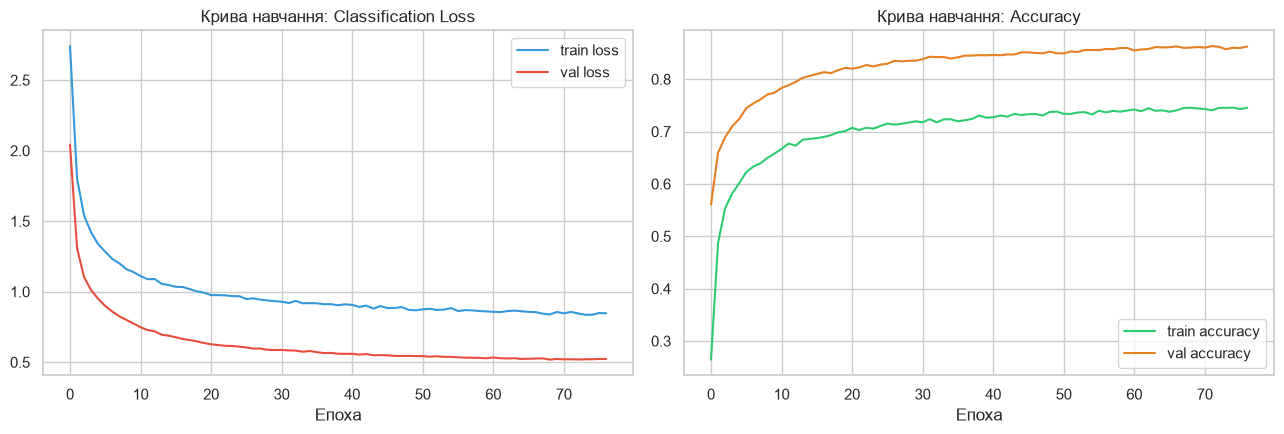

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(clf_history.history["loss"], label="train loss", color="#3498db")
axes[0].plot(clf_history.history["val_loss"], label="val loss", color="#e74c3c")
axes[0].set_title("Крива навчання: Classification Loss")
axes[0].set_xlabel("Епоха")
axes[0].legend()

axes[1].plot(clf_history.history["accuracy"], label="train accuracy", color="#2ecc71")
axes[1].plot(clf_history.history["val_accuracy"], label="val accuracy", color="#e67e22")
axes[1].set_title("Крива навчання: Accuracy")
axes[1].set_xlabel("Епоха")
axes[1].legend()

plt.tight_layout()
plt.show()

### 3.4 Анімована крива навчання класифікації (accuracy)

In [18]:
train_acc = clf_history.history["accuracy"]
val_acc = clf_history.history["val_accuracy"]
epochs_range_c = list(range(1, len(train_acc) + 1))

fig, ax = plt.subplots(figsize=(7.5, 5))
ax.set_xlim(1, len(train_acc))
ax.set_ylim(0, 1.05)
ax.set_xlabel("Епоха")
ax.set_ylabel("Accuracy")
ax.set_title("Анімація навчання: Classification Accuracy")

line_tr, = ax.plot([], [], color="#2ecc71", linewidth=2, label="train accuracy")
line_vl, = ax.plot([], [], color="#e67e22", linewidth=2, label="val accuracy")
ax.legend(loc="lower right")

def init_c():
    line_tr.set_data([], [])
    line_vl.set_data([], [])
    return line_tr, line_vl

def update_c(frame):
    line_tr.set_data(epochs_range_c[:frame], train_acc[:frame])
    line_vl.set_data(epochs_range_c[:frame], val_acc[:frame])
    return line_tr, line_vl

anim_clf = FuncAnimation(fig, update_c, frames=len(train_acc)+1, init_func=init_c, interval=60, blit=True)
anim_clf.save("classification_training.gif", writer=PillowWriter(fps=15))
plt.close(fig)

HTML('<img src="classification_training.gif">')

---
## 4. Висновки

**Регресія.**
Дані згенеровано за допомогою `make_regression` (33 000 зразків, 10 ознак, 6 інформативних, рівень шуму 15). Побудована повнозв'язна нейронна мережа (64→32→16→1 нейрон, лінійний вихід) навчена мінімізувати MSE. Крива навчання показує стабільне зменшення похибки без ознак значного перенавчання (train та val loss ідуть поруч). Отримане значення MSE на тестовій вибірці наведене вище — чим воно ближче до нуля відносно дисперсії target, тим краще модель апроксимує залежність.

**Класифікація.**
Дані згенеровано за допомогою `make_classification` (33 000 зразків, 20 ознак, 35 класів). Побудована мережа з Batch Normalization та Dropout (128→64→35 з softmax) для стабілізації навчання при великій кількості класів. Використано `EarlyStopping` для запобігання перенавчанню. Матриця плутанини демонструє, наскільки добре модель розрізняє окремі класи — діагональ повинна домінувати; світлі позадіагональні клітинки вказують на класи, які модель плутає між собою (типово для завдань із великою кількістю класів і обмеженою роздільністю).

**Загальний висновок.**
TensorFlow/Keras дозволяє швидко побудувати та навчити нейронні мережі для обох типів задач на синтетичних даних. Якість моделі класифікації з 35 класами обмежена складністю задачі (більше класів → складніше розділити простір ознак), тоді як регресійна модель на цих даних досягає стабільної збіжності завдяки помірній розмірності та контрольованому рівню шуму.